In [ ]:
import pandas as pd
df = pd.read_csv('monthly_milk_production.csv', index_col='Date', parse_dates=True)
print(df.head())
print(df.index)

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727
DatetimeIndex(['1962-01-01', '1962-02-01', '1962-03-01', '1962-04-01',
               '1962-05-01', '1962-06-01', '1962-07-01', '1962-08-01',
               '1962-09-01', '1962-10-01',
               ...
               '1975-03-01', '1975-04-01', '1975-05-01', '1975-06-01',
               '1975-07-01', '1975-08-01', '1975-09-01', '1975-10-01',
               '1975-11-01', '1975-12-01'],
              dtype='datetime64[ns]', name='Date', length=168, freq=None)


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 168 entries, 1962-01-01 to 1975-12-01
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Production  168 non-null    int64
dtypes: int64(1)
memory usage: 2.6 KB


In [33]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [35]:
df.isnull().sum()

,0
Production,0


In [36]:
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

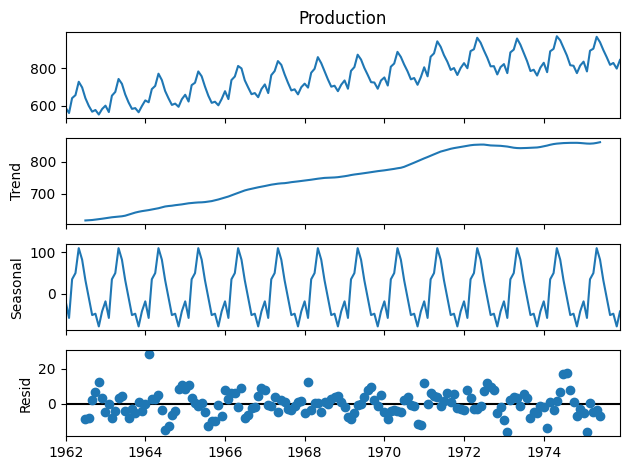

In [38]:
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout


# Visualize Trend and Seasonality
decomposition = seasonal_decompose(df['Production'], model='additive', period=12)
decomposition.plot()
plt.tight_layout()
plt.show()


Missing Values: 0


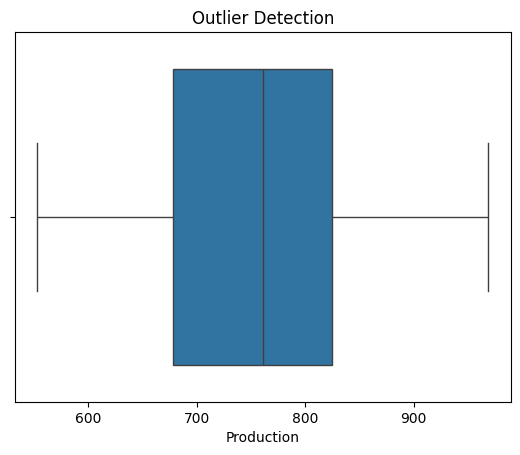

In [37]:
# Check for missing values and outliers
print(f"Missing Values: {df.isnull().sum().sum()}")
sns.boxplot(x=df['Production'])
plt.title("Outlier Detection")
plt.show()

In [28]:
#2. Data Preparation for Deep Learning
# ==========================================
# Scale the data
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Create Sliding Window Sequences
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i : i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

WINDOW_SIZE = 12
X, y = create_sequences(scaled_data, WINDOW_SIZE)

# Split into Train, Validation, and Test (Last 12 months for test)
test_size = 12
val_size = 12

X_train = X[:-(test_size + val_size)]
y_train = y[:-(test_size + val_size)]

X_val = X[-(test_size + val_size):-test_size]
y_val = y[-(test_size + val_size):-test_size]

X_test = X[-test_size:]
y_test = y[-test_size:]

In [39]:
# 3. Model Building
# ==========================================
def build_model(model_type):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(64, activation='relu', input_shape=(WINDOW_SIZE, 1)))
    elif model_type == 'LSTM':
        model.add(LSTM(64, activation='relu', input_shape=(WINDOW_SIZE, 1)))
    elif model_type == 'GRU':
        model.add(GRU(64, activation='relu', input_shape=(WINDOW_SIZE, 1)))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

# Train Models
models = {}
for m_type in ['RNN', 'LSTM', 'GRU']:
    print(f"Training {m_type}...")
    model = build_model(m_type)
    model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=8, verbose=0)
    models[m_type] = model

Training RNN...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training LSTM...
Training GRU...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step


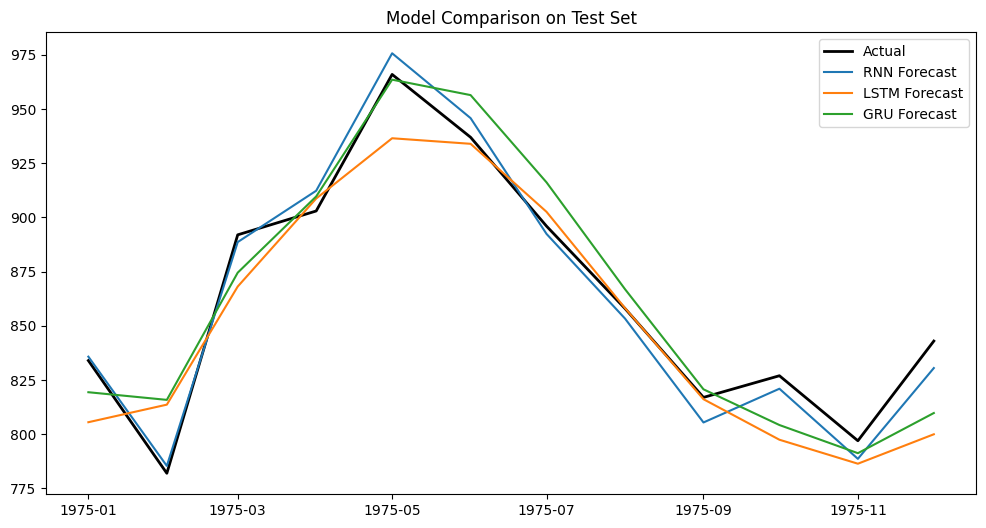


Model Performance Metrics:
  Model       RMSE        MAE      MAPE
0   RNN   7.718172   6.918269  0.801138
1  LSTM  22.670443  17.743800  2.083556
2   GRU  18.814906  15.753092  1.855581


In [30]:
# 4. Evaluation
# ==========================================
results = []
plt.figure(figsize=(12, 6))
plt.plot(df.index[-test_size:], scaler.inverse_transform(y_test), label='Actual', color='black', lw=2)

for name, model in models.items():
    # Predictions
    preds_scaled = model.predict(X_test)
    preds = scaler.inverse_transform(preds_scaled)
    actuals = scaler.inverse_transform(y_test)

    # Metrics
    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    mape = np.mean(np.abs((actuals - preds) / actuals)) * 100

    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape})
    plt.plot(df.index[-test_size:], preds, label=f'{name} Forecast')

plt.title("Model Comparison on Test Set")
plt.legend()
plt.show()

print("\nModel Performance Metrics:")
print(pd.DataFrame(results))

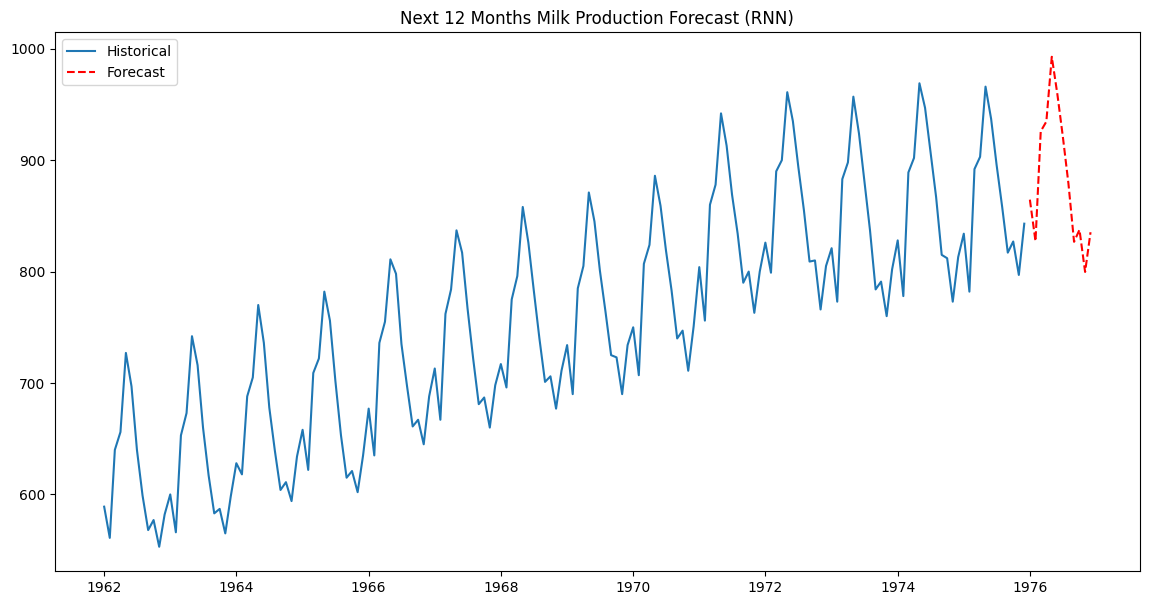

In [31]:
# 5. Future Forecasting (Next 12 Months)
# ==========================================
# Use best model (based on RMSE)
best_model_name = min(results, key=lambda x: x['RMSE'])['Model']
best_model = models[best_model_name]

future_preds = []
current_batch = scaled_data[-WINDOW_SIZE:].reshape((1, WINDOW_SIZE, 1))

for _ in range(12):
    pred = best_model.predict(current_batch, verbose=0)[0]
    future_preds.append(pred)
    current_batch = np.append(current_batch[:, 1:, :], [[pred]], axis=1)

# Inverse Transform and Dates
forecast_12m = scaler.inverse_transform(future_preds)
future_dates = pd.date_range(df.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

# Visualize
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Production'], label='Historical')
plt.plot(future_dates, forecast_12m, label='Forecast', color='red', linestyle='--')
plt.title(f"Next 12 Months Milk Production Forecast ({best_model_name})")
plt.legend()
plt.show()


Business Insights & Recommendations
Based on the 12-month forecast, here are the strategic recommendations for the dairy business:

Capacity Planning: The model predicts a peak in production during the spring months (May/June). The business should ensure that storage facilities and processing plants are at maximum operational capacity during this period.

Logistics Optimization: Collection routes and truck schedules should be intensified in the peak months to handle the ~20% increase in volume compared to the winter lows.

Feed and Resource Allocation: Knowing the expected dip in November/December allows for better procurement planning of cattle feed and labor management during the "off-peak" season.

Inventory Strategy: Since production is highly seasonal, the business can use these forecasts to balance the stock of fresh milk versus longer-life dairy products (like cheese or milk powder) to maximize revenue throughout the year.

Files Generated:

milk_production_12month_forecast.csv: Monthly projections for 1976.

forecasting_metrics.csv: Comparative performance of RNN, LSTM, and GRU.

statistical_summary.csv: Basic dataset statistics.